In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
import seaborn as sns

In [2]:
naive_training = pd.read_csv('../Experiment 2 - Impersonation Detection/naive_training.csv')
gaussian_copula_training = pd.read_csv('../Experiment 2 - Impersonation Detection/gaussian_copula_training.csv')
gan_training = pd.read_csv('../Experiment 2 - Impersonation Detection/gan_training.csv')
vae_training = pd.read_csv('../Experiment 2 - Impersonation Detection/vae_training.csv')

naive_testing = pd.read_csv('../Experiment 2 - Impersonation Detection/naive_testing.csv')
gaussian_copula_testing = pd.read_csv('../Experiment 2 - Impersonation Detection/gaussian_copula_testing.csv')
gan_testing = pd.read_csv('../Experiment 2 - Impersonation Detection/gan_testing.csv')
vae_testing = pd.read_csv('../Experiment 2 - Impersonation Detection/vae_testing.csv')

combined_training = pd.concat([naive_training, gaussian_copula_training, gan_training, vae_training])
print(len(combined_training))

combined_testing = pd.concat([naive_testing, gaussian_copula_testing, gan_testing, vae_testing])
print(len(combined_testing))




36000
12000


### Remove Duplicates

In [3]:
combined_training.drop_duplicates(inplace=True)

combined_training.reset_index(inplace=True)

combined_training.drop(labels=['index', 'Unnamed: 0'], axis=1, inplace=True)

print(len(combined_training))


combined_testing.drop_duplicates(inplace=True)

combined_testing.reset_index(inplace=True)

combined_testing.drop(labels=['index', 'Unnamed: 0'], axis=1, inplace=True)

print(len(combined_testing))

22500
7500


<Axes: >

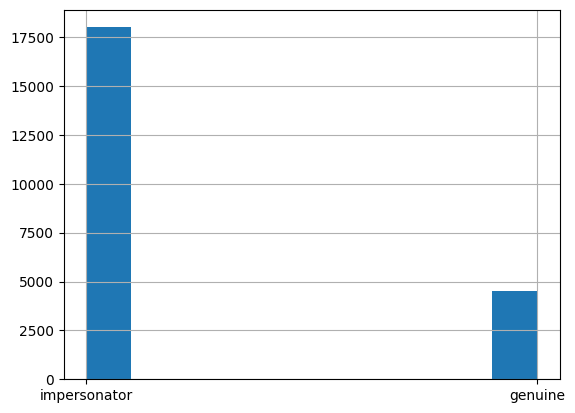

In [4]:
combined_training['label'].hist()

<Axes: >

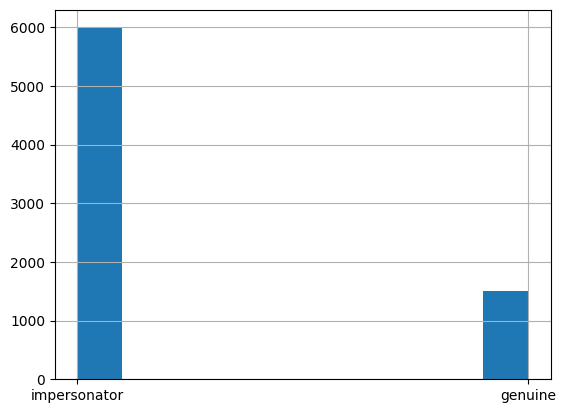

In [5]:
combined_testing['label'].hist()

In [11]:
genuine_train = combined_training.loc[combined_training['label'] == 'genuine']
impersonator_train = combined_training.loc[combined_training['label'] == 'impersonator']

print(len(genuine_train))
print(len(impersonator_train))

4500
18000


In [12]:
genuine_test = combined_testing.loc[combined_testing['label'] == 'genuine']
impersonator_test = combined_testing.loc[combined_testing['label'] == 'impersonator']

print(len(genuine_test))
print(len(impersonator_test))

1500
6000


In [8]:
classification = TabularPredictor.load("../models/classification")
impersonation_detection = TabularPredictor.load("../models/impersonation_detection")

In [27]:
authentication_results = pd.DataFrame(columns=['traces_provided', 'accuracy', 'balanced_accuracy', 'mcc'])

max_traces = 10

for traces_for_this_run in range(2, max_traces + 1):
    print(traces_for_this_run)

    # prep attempts df with right number of feature columns
    authentication_attempts = pd.DataFrame(columns=['label'])
    for i in range(traces_for_this_run):
        authentication_attempts[f'attempt_{i+1}'] = pd.Series([], name=f'attempt_{i}')
    
    # Cycle through rows of genuine data in groups of traces_for_this_run
    # runs the impersonation detection model then the classification model
    previous_df_chunk = 0
    for df_chunk_index in range(traces_for_this_run, len(genuine_train), traces_for_this_run):
        single_auth_attempt = {}
        
        impersonation_prediction = impersonation_detection.predict(genuine_train[previous_df_chunk:df_chunk_index])
        
        
        
        
        for auth_index, single_prediction in enumerate(impersonation_prediction):
            single_auth_attempt[f'attempt_{auth_index}'] = single_prediction
        previous_df_chunk = df_chunk_index
    
    

    # print(authentication_attempts)

    # # prep the data to train/test
    # authentication_attempts = authentication_attempts.sample(frac=1).reset_index(drop=True)
    # auth_train = authentication_attempts[:int(len(authentication_attempts) * 0.8)]
    # auth_test = authentication_attempts[int(len(authentication_attempts) * 0.8):]

    # # train and test
    # predictor = TabularPredictor(label='label').fit(auth_train, num_gpus=1, presets='medium_quality')
    # y_pred = predictor.predict(auth_test)
    # y_pred_proba = predictor.predict_proba(auth_test)
    # results = predictor.evaluate(auth_test)



    # new_results = {'traces_provided':traces_for_this_run, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    # authentication_results.loc[len(authentication_results)] = (new_results)

2
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
impersonator
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
genuine
genuine
------
-----
g

KeyboardInterrupt: 

In [210]:
authentication_results

,traces_provided,roc_auc,f1,precision,recall
0,2,0.965818,0.928485,0.876430,0.987113
1,3,0.980216,0.949458,0.926056,0.974074
2,4,0.979454,0.928571,0.892157,0.968085
3,5,0.985869,0.948949,0.908046,0.993711
4,6,0.981973,0.954064,0.944056,0.964286
5,7,0.980834,0.950000,0.919355,0.982759
6,8,0.992221,0.964467,0.959596,0.969388
7,9,0.992967,0.960000,0.933333,0.988235
8,10,0.989428,0.934211,0.910256,0.959459


<Axes: xlabel='traces_provided', ylabel='value'>

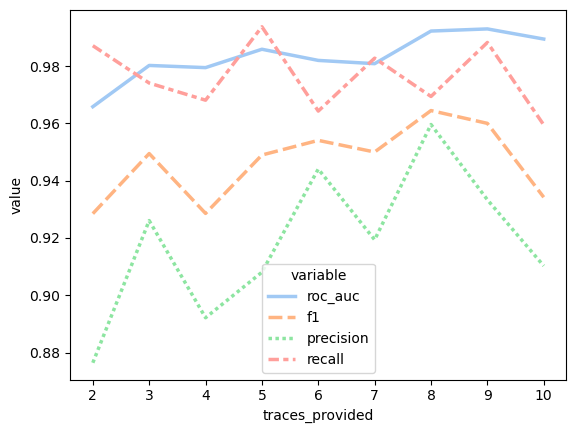

In [211]:
sns.lineplot(data=pd.melt(authentication_results, ['traces_provided']), x='traces_provided', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [62]:
adversary_detection_predictor = TabularPredictor.load("anomaly_detection")
iot_device_classifier_predictor = TabularPredictor.load("classification")

In [63]:
authentication_results = pd.DataFrame(columns=['traces_provided', 'roc_auc', 'f1', 'precision', 'recall'])

traces_for_this_run = 8
print(traces_for_this_run)

# prep attempts df with right number of feature columns
authentication_attempts = pd.DataFrame(columns=['label'])
for i in range(traces_for_this_run):
    authentication_attempts[f'attempt_{i}'] = pd.Series([], name=f'attempt_{i}')

print(authentication_attempts)

# auth testing for devices with bad label
for single_bad_device in bad_testing_sorted:
    print(single_bad_device)
    for i in range(0, len(single_bad_device), traces_for_this_run):
        print(i)
        chunk = single_bad_device.iloc[i:i+traces_for_this_run]
        if len(chunk) == traces_for_this_run:
            # process or print the current chunk
            preds = adversary_detection_predictor.predict(chunk)
            # print(preds)
            new_row = {'label': 'bad'}
            for i, pred in enumerate(preds):
                if pred == 'good':
                    id_prediction = iot_device_classifier_predictor.predict(pd.DataFrame(chunk))
                    if id_prediction.iloc[i] == chunk.iloc[i].loc['label']:
                        new_row[f'attempt_{i}'] = 'match'
                    else:
                        new_row[f'attempt_{i}'] = 'mismatch'
                else:
                    new_row[f'attempt_{i}'] = 'malicious'
            authentication_attempts.loc[len(authentication_attempts)]= new_row

# auth testing for devices with good label
for single_good_device in good_testing_sorted:
    print(single_good_device)
    for i in range(0, len(single_good_device), traces_for_this_run):
        print(i)
        chunk = single_good_device.iloc[i:i+traces_for_this_run]
        if len(chunk) == traces_for_this_run:
            preds = adversary_detection_predictor.predict(chunk)
            # print(preds)
            new_row = {'label': 'good'}
            for i, pred in enumerate(preds):
                if pred == 'good':
                    id_prediction = iot_device_classifier_predictor.predict(pd.DataFrame(chunk))
                    if id_prediction.iloc[i] == chunk.iloc[i].loc['label']:
                        new_row[f'attempt_{i}'] = 'match'
                    else:
                        new_row[f'attempt_{i}'] = 'mismatch'
                else:
                    new_row[f'attempt_{i}'] = 'malicious'
            authentication_attempts.loc[len(authentication_attempts)]= new_row

# prep the data to train/test
authentication_attempts = authentication_attempts.sample(frac=1).reset_index(drop=True)
auth_train = authentication_attempts[:int(len(authentication_attempts) * 0.8)]
auth_test = authentication_attempts[int(len(authentication_attempts) * 0.8):]

# train and test
# predictor = TabularPredictor(label='label').fit(auth_train, num_gpus=1, presets='good_quality')
# y_pred = predictor.predict(auth_test)
# y_pred_proba = predictor.predict_proba(auth_test)
# results = predictor.evaluate(auth_test)



# new_results = {'traces_provided':traces_for_this_run, 'roc_auc':results['roc_auc'], 'f1':results['f1'], 'precision':results['precision'], 'recall':results['recall']}
# authentication_results.loc[len(authentication_results)] = (new_results)

8
Empty DataFrame
Columns: [label, attempt_0, attempt_1, attempt_2, attempt_3, attempt_4, attempt_5, attempt_6, attempt_7]
Index: []
     Feature 0  Feature 1  Feature 2  Feature 3  Feature 4  Feature 5  \
0        164.8      166.2      168.3      166.4      168.8      167.8   
1        164.8      168.4      168.7      164.4      166.6      166.1   
2        165.7      168.8      165.3      166.6      168.9      167.5   
3        166.7      168.2      167.8      167.4      168.7      165.1   
4        164.1      166.1      166.5      166.9      165.4      167.5   
..         ...        ...        ...        ...        ...        ...   
387      163.0      191.5      176.0      154.3      158.8      165.0   
388      164.2      153.5      135.4      167.9      169.7      176.0   
389      154.7      179.2      165.4      192.4      172.9      176.4   
390      171.3      155.4      179.6      171.1      162.6      161.7   
391      165.9      192.7      147.2      162.7      158.9      

predictor = TabularPredictor(label='label', eval_metric='f1').fit(auth_train, num_gpus=1, presets='best_quality', time_limit=3600)
y_pred = predictor.predict(auth_test)
y_pred_proba = predictor.predict_proba(auth_test)
results = predictor.evaluate(auth_test)

In [ ]:
predictor = TabularPredictor(label='label', eval_metric='f1').fit(auth_train, num_gpus=1, presets='high_quality', time_limit=3600) 
y_pred = predictor.predict(auth_test) 
y_pred_proba = predictor.predict_proba(auth_test) 
results = predictor.evaluate(auth_test)

No path specified. Models will be saved in: "AutogluonModels/ag-20241103_003403"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.11.10
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #48-Ubuntu SMP PREEMPT_DYNAMIC Fri Sep 27 14:04:52 UTC 2024
CPU Count:          12
Memory Avail:       25.81 GB / 30.82 GB (83.7%)
Disk Space Avail:   146.09 GB / 341.37 GB (42.8%)
Presets specified: ['high_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
DySt

In [ ]:
results

In [ ]:
predictor.leaderboard()

In [87]:
# will return the path to the cloned predictor, identical to save_path_clone_opt
path_clone_opt = predictor.clone_for_deployment(path='authentication')

FileExistsError: [Errno 17] File exists: 'authentication'

In [88]:
predictor_clone_opt = TabularPredictor.load(path='authentication')

In [89]:
predictor_clone_opt.leaderboard(auth_test)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,CatBoost_r5_BAG_L1_FULL,0.976959,None,f1,0.001582,NaN,0.014394,0.001582,NaN,0.014394,1,True,69
1,CatBoost_r49_BAG_L1_FULL,0.976959,None,f1,0.001603,NaN,0.020316,0.001603,NaN,0.020316,1,True,53
2,CatBoost_r177_BAG_L1_FULL,0.976744,None,f1,0.001728,NaN,0.010644,0.001728,NaN,0.010644,1,True,12
3,LightGBM_r135_BAG_L1_FULL,0.976744,None,f1,0.001751,NaN,0.322564,0.001751,NaN,0.322564,1,True,80
4,CatBoost_r86_BAG_L1_FULL,0.976744,None,f1,0.002047,NaN,0.374120,0.002047,NaN,0.374120,1,True,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,NeuralNetTorch_r158_BAG_L1_FULL,0.946429,None,f1,0.003927,NaN,1.221014,0.003927,NaN,1.221014,1,True,49
105,NeuralNetFastAI_r103_BAG_L1_FULL,0.920000,None,f1,0.015954,NaN,0.199288,0.015954,NaN,0.199288,1,True,36
106,NeuralNetFastAI_r172_BAG_L1_FULL,0.000000,None,f1,0.003993,NaN,0.089318,0.003993,NaN,0.089318,1,True,86
107,NeuralNetFastAI_r194_BAG_L1_FULL,0.000000,None,f1,0.005946,NaN,0.168065,0.005946,NaN,0.168065,1,True,93


In [90]:
size_original = predictor.disk_usage()
size_opt = predictor_clone_opt.disk_usage()
print(f'Size Original:  {size_original} bytes')
print(f'Size Optimized: {size_opt} bytes')
print(f'Optimized predictor achieved a {round((1 - (size_opt/size_original)) * 100, 1)}% reduction in disk usage.')

Size Original:  188101387 bytes
Size Optimized: 56806415 bytes
Optimized predictor achieved a 69.8% reduction in disk usage.
